# Fault Detection in District Heating D0042E
## Task 1 (Data exploration)
Loads labeled_data.csv into a pandas DataFrame and parses timestamp_utc as the index.

In [1]:
import pandas as pd

df = pd.read_csv('labeled_data.csv')
# Convert timestamp column from a string to datetime format
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])
df = df.set_index("timestamp_utc")

Reports the shape of the DataFrame, the time span it covers, and number of fault episodes.

In [2]:
print(df.columns)
print("Amount of samples:",len(df))

duration = df.index.max() - df.index.min()
print("Duration:", duration)

faults = df[df["fault_active"] == 1]
# Counts number of faults by identifying time gaps bigger then 20s
num_faults = (faults.index.to_series().diff() > pd.Timedelta("20s")).sum()+1
print(f"Number faults: {num_faults}")

Index(['ts_ms', 'temperature/room1', 'temperature/room2', 'temperature/room3',
       'temperature/supply', 'temperature/outside', 'flow/room1', 'flow/room2',
       'flow/room3', 'return/room1', 'return/room2', 'return/room3',
       'fault_active', 'fault_type', 'fault_room'],
      dtype='str')
Amount of samples: 80640
Duration: 13 days 23:59:45
Number faults: 135


Creates a subset of the DataFrame that only contains data from 2026-04-15.

In [3]:
df_subset = df[df.index.date == pd.to_datetime("2026-04-15").date()]

Plots the time series of all 11 sensor channels, separated by room. The fault intervals are shaded and color-coded by  fault type, either window_open as blue or radiator_blocked as red. 

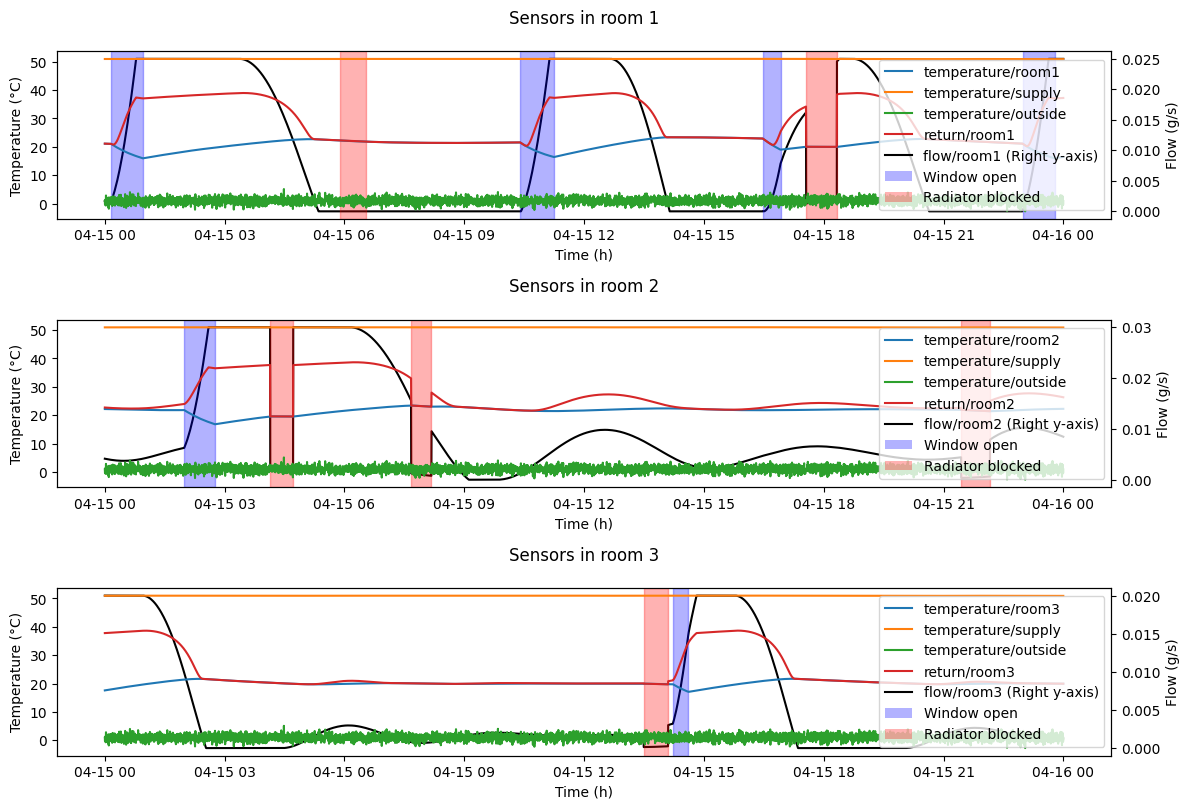

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

cols = [
    "temperature/room",
    "temperature/supply",
    "temperature/outside",
    "flow/room",
    "return/room",
]

fault_colors = {
    "window_open":"blue",
    "radiator_blocked":"red"
}

fig, axes = plt.subplots(3,1)
fig.set_size_inches(12,8)

for i, ax in enumerate(axes):
    #Creates second y-axis
    ax2 = ax.twinx()  
    ax.set_zorder(2)
    ax2.set_zorder(1)
    ax.patch.set_visible(False)
    
    for col in cols:
        if col[-4:] == "room":
            col += str(i+1)
        if "flow" in col:
            ax2.plot(df_subset[col], color="black", label= ("flow/room"+ str(i+1)+ " (Right y-axis)"))
        else:
            ax.plot(df_subset[col], label=col)

    # Identifies fault windows
    faults = df_subset[df_subset["fault_room"] == f"room{i+1}"]
    groups = (faults.index.to_series().diff() > pd.Timedelta("20s")).cumsum()

    #Shade fault windows
    for _, g in faults.groupby(groups):
        ax.axvspan(
            g.index.min(),
            g.index.max(),
            color=fault_colors[g["fault_type"].iloc[0]],
            alpha=0.3
        )
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.6)

    ax.set_title(f"Sensors in room {i+1}",pad=20)
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Temperature (°C)")
    ax2.set_ylabel("Flow (g/s)")

    fault_patches = [
        Patch(facecolor="blue", alpha=0.3, label="Window open"),
        Patch(facecolor="red", alpha=0.3, label="Radiator blocked")
    ]
    
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2 + fault_patches, labels + labels2 + [p.get_label() for p in fault_patches])

plt.show()

## Task 2 (Feature Engineering)

Builds a binary target vector.

In [5]:
import numpy as np

y = np.where(df["fault_type"].isna(), 0, 1)

Builds a feature matrix X from raw values, setpoint errors, rolling statistics (mean of each channel over a sliding window of N samples), and cross-channel features (supply minus return per room, and an approximate
radiator power). 

In [6]:
feature_cols = [
    "temperature/room1",
    "temperature/room2",
    "temperature/room3",
    "temperature/supply",
    "temperature/outside",
    "flow/room1",
    "flow/room2",
    "flow/room3",
    "return/room1",
    "return/room2",
    "return/room3",
]
# Features from raw values
X_raw = df[feature_cols].to_numpy()
# Features from setpoint errors
X_sp_err = np.array([[21,22,20]]) - X_raw[:,0:3]
# Cross-channel features
X_P = X_raw[:,5:8]*(X_raw[:,3:4] - X_raw[:,-3:])

# Rolling statistics, gives historical context and can show trends. 
N = 5
lst_mean = []
lst_std = []

for i in range(X_raw.shape[0] - (N-1)):
    # Compute mean for each feature over the window
    lst_mean.append(np.mean(X_raw[i:i+N,:], axis = 0))
    # Compute standard deviation for each feature over the window
    lst_std.append(np.std(X_raw[i:i+N,:], axis = 0))

# Convert lists to NumPy arrays
X_mean = np.vstack(lst_mean)
X_std = np.vstack(lst_std)

# Combine features, we align everything by removing the first (N-1) samples due to windowing
X = np.concatenate([X_raw[(N-1):,:], X_sp_err[(N-1):,:], X_P[(N-1):,:], X_mean],axis=1)#, X_std], axis = 1)
y = y[(N-1):]

Reports the dataset shape and the class balance. 

In [7]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

no_fault = (y == 0).sum()/len(y)
fault = (y == 1).sum()/len(y)

print(f"Class balance:")
print(f"No faults: {no_fault}")
print(f"fault: {fault}")

X shape: (80636, 28)
y shape: (80636,)
Class balance:
No faults: 0.7442085420903815
fault: 0.25579145790961855


## Task 3 (Train and Evaluate the Detector) 
Splits the dataset chronologically into training, validation, and test sets.

In [8]:
split_index_1 = int(len(y)*0.7)
split_index_2 = int(len(y)*0.85)

# Splits into 70% training data, 15% validation data, 15% test data
X_train = X[0:split_index_1,:]
y_train = y[0:split_index_1]

X_val = X[split_index_1:split_index_2,:]
y_val = y[split_index_1:split_index_2]

X_test = X[split_index_2:,:]
y_test = y[split_index_2:]

This block imports all required libraries.

In [9]:
# Imports PyTorch, NN module, functions, tools for handling datasets and batching, and standardscalar
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Imports a function to create a deep copy of an object
from copy import deepcopy

Defines architecture of the neural network using a custom class called FaultNet, which inherits from torch.nn.Module.

In [10]:
# Defines how many samples are processed per training step, more stable gradients
BATCH_SIZE = 64

# Defines neural network class and inherits from nn.Module
class FaultNet(nn.Module):
    def __init__(self, n_features, n_outputs):
        super().__init__() # Calls parent class (nn.Module) constructor
        # Creates a sequential model
        self.net = nn.Sequential(
            nn.Linear(n_features, 32), # Layer 1
            nn.ReLU(), # Activation function (non-linearity)
            nn.Linear(32, 16), # Layer 2
            nn.ReLU(),
            nn.Linear(16, n_outputs) # Output layer
        )
    # Defines how data flows through the model
    def forward(self, x):
        return self.net(x)

This block defines a function that converts raw NumPy arrays into PyTorch-compatible datasets.

In [11]:
# Defines function that takes raw data (NumPy arrays) and a shuffle flag, returns a dataset and a dataloader
def get_dataset_loader(X,y,shuffle):
    # Converts X and y to PyTorch tensors (multi-dim arrays of numbers)
    X_tensor = torch.tensor(X, dtype=torch.float32)  
    y_tensor = torch.tensor(y, dtype=torch.long)

    # Created TensorDataset (Defines how data is paired)
    dataset = TensorDataset(X_tensor, y_tensor) 
    # Created DataLoader (feeds data to model in chunks)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle) 
    return dataset, loader

Performs feature standardization and prepares the training, validation, and test datasets.

In [12]:
# Feature standardization on training data to prevent data leakage
scaler = StandardScaler()
scaler.fit(X_train)

train_set, train_loader = get_dataset_loader(scaler.transform(X_train),y_train,True)
val_set, val_loader = get_dataset_loader(scaler.transform(X_val),y_val,False)
test_set, test_loader = get_dataset_loader(scaler.transform(X_test),y_test,False)

Initializes the model and defines the training configuration.

In [13]:
# Creates neural network with 39 features and 3 classes
model = FaultNet(28,2)

# Class weighting in the loss
# Idea: rare classes should have higher weight, common classes lower weight
freq = torch.tensor([no_fault, fault])
weights = (1.0 / freq).float()

# Normalize weights so that their mean equals 1
# This keeps the overall loss scale stable while preserving the relative class importance
weights = weights / weights.sum() * len(freq)

# Defines loss function, CrossEntropyLoss for multi-class classification
criterion = nn.CrossEntropyLoss(weight=weights)

# Creates the optimization algorithm (Stochastic Gradient Descent), updates the model’s parameters during training, lr = learning rate (steps), weight_decay penalizes high weights
optimizer = torch.optim.SGD(model.parameters(),lr=0.005, weight_decay= 0.025)

# Defines how many times the model will go through the entire training dataset
epochs = 40 #200

# Tracks best model during training
best_loss = float('inf')
best_model = None

This block contains the full training and validation loop.

In [14]:
for epoch in range(epochs):
    
    # Puts the model into training mode
    model.train()
    for features, targets in train_loader:
        # features shape: (BATCH_SIZE,39)
        # targets shape: (BATCH_SIZE,)
        
        # Forward pass
        predictions = model(features)
        # predictions shape: (BATCH_SIZE,3)

        # Calculate loss
        loss = criterion(predictions, targets)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Clear gradients
        optimizer.zero_grad()
    
    losses = []
    # Puts the model into evaluation mode
    model.eval()
    for features, targets in val_loader:
        # features shape: (BATCH_SIZE,39)
        # targets shape: (BATCH_SIZE,)
        
        # Forward pass, disable gradient computation
        with torch.no_grad():
            predictions = model(features)

        # Add loss to list
        losses.append(criterion(predictions, targets).item())
    # Computes average validation loss
    loss = sum(losses)/len(losses)

    # Saves best model
    if loss<best_loss:
        best_loss = loss
        best_model = deepcopy(model)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss}")

Epoch [1/40] Loss: 0.6775236079301784
Epoch [2/40] Loss: 0.6601897697284739
Epoch [3/40] Loss: 0.6437669724383682
Epoch [4/40] Loss: 0.6240872217233849
Epoch [5/40] Loss: 0.6118965521060601
Epoch [6/40] Loss: 0.5926003741524207
Epoch [7/40] Loss: 0.5830528203141753
Epoch [8/40] Loss: 0.5755600285120112
Epoch [9/40] Loss: 0.5656749454755632
Epoch [10/40] Loss: 0.5564218869127294
Epoch [11/40] Loss: 0.5483825063263928
Epoch [12/40] Loss: 0.5559618606296166
Epoch [13/40] Loss: 0.5354454835098257
Epoch [14/40] Loss: 0.5368669166293725
Epoch [15/40] Loss: 0.5320421501442238
Epoch [16/40] Loss: 0.5260725739614043
Epoch [17/40] Loss: 0.5167580540218051
Epoch [18/40] Loss: 0.5153723986297057
Epoch [19/40] Loss: 0.5203863053173615
Epoch [20/40] Loss: 0.5084645666931041
Epoch [21/40] Loss: 0.49016123533091216
Epoch [22/40] Loss: 0.49715411521139596
Epoch [23/40] Loss: 0.49019576699803113
Epoch [24/40] Loss: 0.48662496590740467
Epoch [25/40] Loss: 0.49776984435856025
Epoch [26/40] Loss: 0.4861339

Evaluation of the model on the test set using several metrics, including accuracy, precision, recall, F1-score, and the confusion matrix.

In [15]:
# Test model
confusion_matrix = np.zeros((2,2))
# Counts correct predictions
correct = 0
# Counts total samples
total = 0

model.eval()
for features, targets in test_loader:
    # features shape: (BATCH_SIZE,39)
    # targets shape: (BATCH_SIZE,)
    
    # Forward pass, also picks the index of the highest score per sample
    predictions = torch.argmax(best_model(features),1)

    # Each iteration handles one sample
    for p, t in zip(predictions,targets):
        # Updates confusion matrix
        confusion_matrix[t,p]+=1
        total+=1
        if p==t:
            correct+=1
    
# True is rows (left in matrix) and predicted is columns (up in matrix)
print("Confusion_matrix:")
print(confusion_matrix.astype(int))
print("Accuracy:")
print(f"{100*correct/total:.1f} %")
print("Precision (per class):")
precisions = confusion_matrix[np.eye(2,dtype=bool)]/np.sum(confusion_matrix,axis=0)
print(precisions)
print("Recall (per class):")
recalls = confusion_matrix[np.eye(2,dtype=bool)]/np.sum(confusion_matrix,axis=1)
print(recalls)
print("F1 score (per class):")
F1_scores = (2*precisions*recalls)/(precisions+recalls)
print(F1_scores)
print("F1 score (Micro vs Macro averaged):") 
print((2*np.mean(precisions)*np.mean(recalls))/(np.mean(precisions)+np.mean(recalls)), np.mean(F1_scores))

Confusion_matrix:
[[7000 1609]
 [1240 2247]]
Accuracy:
76.4 %
Precision (per class):
[0.84951456 0.58272822]
Recall (per class):
[0.81310257 0.64439346]
F1 score (per class):
[0.83090985 0.61201144]
F1 score (Micro vs Macro averaged):
0.7223795301972016 0.7214606428739183


In cases where there is no flow through the radiator, it is not possible to differentiate whether it is due to a blockage or naturally no flow (for instance when the temperature is to high in the room). This explains why it sometimes misclassifies no fault with radiater blockage. 

Saves model in a .pt formal and the feature scaler in a .pkl formal.

In [ ]:
import pickle

# save
with open('scaler.pkl','wb') as f:
    pickle.dump(scaler,f)
torch.save(best_model,"model.pt")

# Task 5 (Model comparsions)

Trains a Random Forrest with the same training data.

In [16]:
from sklearn.ensemble import RandomForestClassifier

cw = {0:weights[0],1:weights[1]}
clf = RandomForestClassifier(max_depth=4,class_weight=cw)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print(sum(y_pred==y_test)/len(y_test))

0.6035879629629629


In [ ]:
with open('tree_model.pkl','wb') as f:  #ANTONS KOD
    pickle.dump(clf,f)